# Exploration of Black-Scholes Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')  # so the notebook can find src/

from src.black_scholes import calc_d1_d2, bs_option_price
from src.black_scholes import bs_delta, bs_vega

## Option vs. Spot

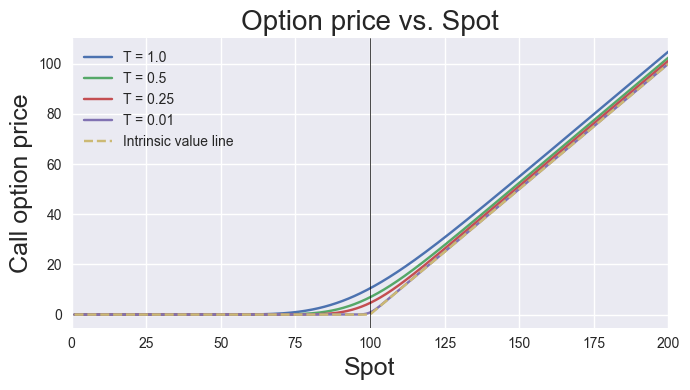

In [7]:
# Parameters
strike = 100
rate = 0.05
sigma = 0.2
expiries = [1.0, 0.5, 0.25, 0.01]  # four curves, one per expiry

spots = np.linspace(1, 200, 500)

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(figsize=(7, 4))

for T in expiries:
    # 1. compute d1, d2 for all spots at this expiry
    d1, d2 = calc_d1_d2(spots, strike, rate, sigma, T)

    # 2. compute call price for all spots
    call_prices = bs_option_price(spots, strike, rate, sigma, T, option_type='call')

    # 3. plot with label f"T = {T}"
    ax.plot(spots, call_prices, label=f"T = {T}")
    

# 4. add a dashed line for the intrinsic value: max(S - K, 0)
ax.plot(spots, np.maximum(spots - strike, 0), '--', label="Intrinsic value line")

# 5. add vertical line at strike
ax.axvline(strike, color="black", linewidth=0.5)

# 6. labels, title, legend, grid
ax.set_xlabel("Spot", fontsize=18)
ax.set_ylabel("Call option price", fontsize=18)
ax.set_title("Option price vs. Spot", fontsize=20)
ax.set_xlim(0, 200)
# ax.grid()
ax.legend()

plt.tight_layout()
plt.savefig('../results/01_call_price_vs_spot.png', dpi=150)
plt.show()

The hockey stick shape is clear, T=0.01 collapses onto the intrinsic value line, and the curves fan out correctly with time value highest at-the-money. 

### Observations
* The gap between the T=1.0 curve and the intrinsic value line at spot=100. That gap is the time value of the option. As the T decreases, the gap between the curve the intrinsic line decreases. Time value decays as T $\rightarrow$ 0.

* Far to the right, say at spot=180, all four curves converge toward the same line. Deep in-the-money, the call behaves like owning the stock minus a fixed cost. The curve approaches $S - Ke^{-rT}$. For large S the difference is small, which is why they appear to converge to the same line visually

* Far to the left, say at spot=20, all curves are near zero but not exactly zero. That small positive value is called time value or more precisely the optionality premium. The holder has the right but not the obligation, so even a deeply out-of-the-money option has some value as long as T>0, because there is always some probability under the log-normal distribution that the stock reaches the strike. That probability never becomes exactly zero until expiry.

* The curves are not symmetric around the strike. The right side fans out more than the left side collapses.Under GBM, the stock price is log-normally distributed. It can rise without bound but cannot fall below zero. So the distribution of future spot prices is skewed, there's more probability mass on large upside moves than on equivalent downside moves. This asymmetry means the call price fans out more to the right than the put price would fan out to the left.

## Delta vs. Spot

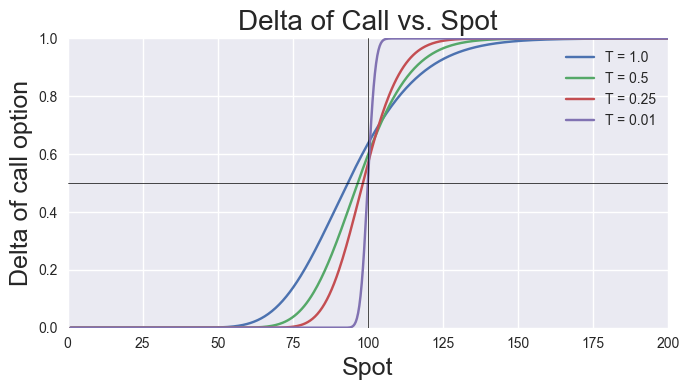

In [8]:
# Parameters
strike = 100
rate = 0.05
sigma = 0.2
expiries = [1.0, 0.5, 0.25, 0.01]  # four curves, one per expiry

spots = np.linspace(1, 200, 500)

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(figsize=(7, 4))

for T in expiries:
    # 1. compute d1, d2 for all spots at this expiry
    d1, _ = calc_d1_d2(spots, strike, rate, sigma, T)  # not using d2

    # 2. compute call price for all spots
    delta = bs_delta(d1, option_type='call')

    # 3. plot with label f"T = {T}"
    ax.plot(spots, delta, label=f"T = {T}")
    

# 5. add vertical line at strike
ax.axvline(strike, color="black", linewidth=0.5)
ax.axhline(0.5, color="black", linewidth=0.5)


# 6. labels, title, legend, grid
ax.set_xlabel("Spot", fontsize=18)
ax.set_ylabel("Delta of call option", fontsize=18)
ax.set_title("Delta of Call vs. Spot", fontsize=20)
ax.set_xlim(0, 200)
ax.set_ylim(0, 1)
# ax.grid()
ax.legend()

plt.tight_layout()
plt.savefig('../results/01_delta_of_call_vs_spot.png', dpi=150)
plt.show()

* As the spot price goes to 0, a call option will end up out-of-the-money. If we think delta in terms of hedge ratio, it should approach 0 because there is no longer any uncertainty in the option price, given that the option will not be exercised. Conversely, as the spot price goes to infinity, the call option price approaches the spot price. To hedge that position, a full share of stock is required, meaning delta approaches 1.

## Option price vs. Time to maturity

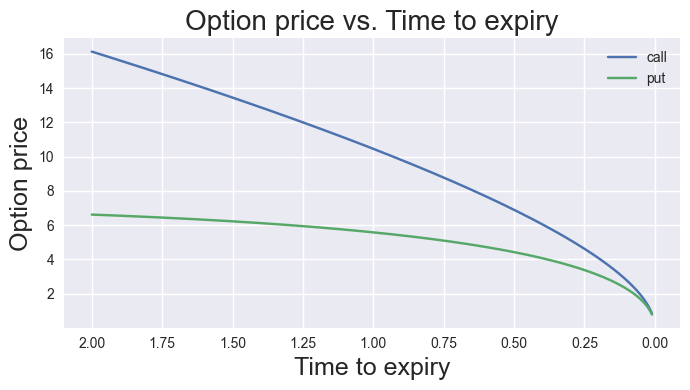

In [9]:
# Parameters
spot = 100
strike = 100
rate = 0.05
sigma = 0.2
times = np.linspace(0.01, 2.0, 500)  # T from near-zero to 2 years

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(figsize=(7, 4))


# Compute call and put prices
call_prices = bs_option_price(spot, strike, rate, sigma, times, option_type='call')
put_prices = bs_option_price(spot, strike, rate, sigma, times, option_type='put')

# Plot with label f"T = {T}"
ax.plot(times, call_prices, label='call')
ax.plot(times, put_prices, label='put')
    
# labels, title, legend, grid
ax.set_xlabel("Time to expiry", fontsize=18)
ax.set_ylabel("Option price", fontsize=18)
ax.set_title("Option price vs. Time to expiry", fontsize=20)
# ax.set_xlim(0, 200)
ax.invert_xaxis()
# ax.grid()
ax.legend()

plt.tight_layout()
plt.savefig('../results/01_option_price_vs_expiry.png', dpi=150)
plt.show()

* Option price decay is roughly proportional to $\sqrt{T}$ rather than decaying exponentially. According to the vega formula, $S N'(d_1) \sqrt{T}$, time enters the calculation as a square root. Consequently, decay is non-linear and concave, meaning it accelerates near expiry ($T=0$) and flattens out further away ($T=2$). This $\sqrt{T}$ effect means that theta is larger in magnitude close to expiration.

* Throughout the timeline, the call option is worth more than the put option. For instance, at $T=2$, the call is valued at approximately 16 while the put is around 6.5. This difference is driven by the risk-free rate; holding a call option simulates holding the underlying stock without locking up capital, thereby providing a financing benefit that the put option lacks. This valuation gap widens as time to maturity ($T$) and the risk-free rate ($r$) increase.

* Additionally, the put option decays more rapidly near expiration. As $T \rightarrow 0$, the put converges from below and the call converges from above until they meet at the same point, with the crossover occurring around $T=0.05$ in the plot.

## Vega vs Spot

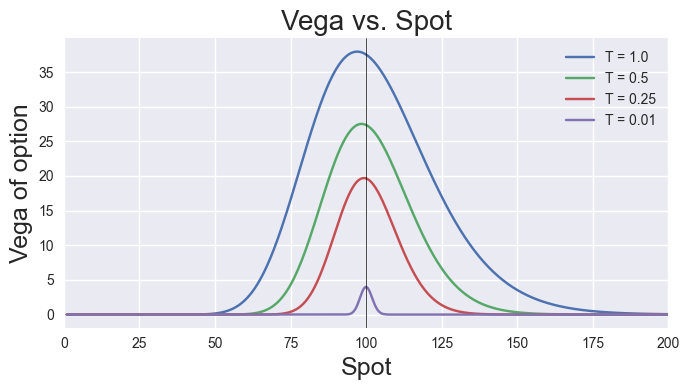

In [10]:
# Parameters
strike = 100
rate = 0.05
sigma = 0.2
expiries = [1.0, 0.5, 0.25, 0.01]  # four curves, one per expiry

spots = np.linspace(1, 200, 500)

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(figsize=(7, 4))

for T in expiries:
    # 1. compute d1, d2 for all spots at this expiry
    d1, _ = calc_d1_d2(spots, strike, rate, sigma, T)  # not using d2

    # 2. compute call price for all spots
    vega = bs_vega(spots, T, d1)

    # 3. plot with label f"T = {T}"
    ax.plot(spots, vega, label=f"T = {T}")
    

# 5. add vertical line at strike
ax.axvline(strike, color="black", linewidth=0.5)


# 6. labels, title, legend, grid
ax.set_xlabel("Spot", fontsize=18)
ax.set_ylabel("Vega of option", fontsize=18)
ax.set_title("Vega vs. Spot", fontsize=20)
ax.set_xlim(0, 200)
ax.legend()

plt.tight_layout()
plt.savefig('../results/01_vega_of_call_vs_spot.png', dpi=150)
plt.show()

*   **ATM Vega is Highest**

    At-the-money (ATM) options have the highest vega. At this point, a small shift in volatility exerts the maximum impact on the probability of the option ending in-the-money. Conversely, for deep in-the-money (ITM) or out-of-the-money (OTM) options, the eventual outcome is already relatively certain, making them less sensitive to changes in volatility.

*   **Identical Formula for Calls and Puts**

    The mathematical formula for vega is given by $S \cdot N'(d_1) \cdot \sqrt{T}$. Because it does not contain terms like $N(d_2)$ or $N(-d_2)$, the equation lacks any parameter that depends on the option type. Consequently, the vega for a call and a put is completely identical. Financially, this occurs because volatility expands the width of the future price distribution symmetrically, meaning both call and put holders benefit equally from an increased dispersion of outcomes.

*   **Vega Decreases as Time to Maturity ($T$) Shrinks**

    As time to maturity decreases, vega falls, meaning options closer to expiration become less sensitive to volatility changes. For an option expiring very soon, an adjustment in implied volatility will barely alter its price because there is insufficient time remaining for that volatility to translate into significant underlying stock movement.

